In [1]:
from collections import defaultdict
import gzip
import seaborn as sns
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pickle

## Weissman CRISPRi data

In [5]:
data = pd.read_csv("TableS3_hCRISPRiv2_libraries.csv")
data.head()

# make all data in caps 

,sgID,gene,transcript,protospacer sequence,selection rank,predicted score,empirical score,off-target stringency,CRISPRi-v2.1 predicted score,Sublibrary,Sublibrary half
0,A1BG_-_58858617.23-P1,A1BG,P1,GGAGACCCAGCGCTAACCAG,1.0,1.008816,NaN,0,0.685071,h3,Top5
1,A1BG_-_58858788.23-P1,A1BG,P1,GGGGCACCCAGGAGCGGTAG,2.0,0.901176,NaN,0,0.782793,h3,Top5
2,A1BG_+_58858964.23-P1,A1BG,P1,GCTCCGGGCGACGTGGAGTG,3.0,0.836188,NaN,0,0.870837,h3,Top5
3,A1BG_-_58858630.23-P1,A1BG,P1,GAACCAGGGGTGCCCAAGGG,4.0,0.827551,NaN,0,0.590668,h3,Top5
4,A1BG_+_58858549.23-P1,A1BG,P1,GGCGAGGAACCGCCCAGCAA,5.0,0.775395,NaN,0,0.492280,h3,Top5


In [6]:
weissman_guides = [x.upper() for x in list(data["protospacer sequence"])]

## Count barcodes

In [111]:
def get_read_dict(fn):
    print(fn)
    counter = defaultdict(lambda: 0)
    with gzip.open(fn,'r') as fin:
        i = 0
        for line in fin:
            i += 1
            if (i % 5000000 == 0): print(i)
            if ((i + 2) % 4 == 0): 
                # change the first letter to G because the first base is often read wrong
                # also read the first 20
                seq = 'G' + line.rstrip()[1:20].decode() 
                counter[seq] += 1
    return(dict(counter))

In [112]:
cd14_up = get_read_dict("../../files/210709Van/out_CTTGTA+ACTGAT.fastq.gz")  # ATCAGT
cd11b_rep2_up = get_read_dict("../../files/210709Van/out_CTTGTA+CCGTCC.fastq.gz")  # GGACGG
cd11b_rep1_up = get_read_dict("../../files/210709Van/out_CTTGTA+GATCAG.fastq.gz")  # CTGATC
cd11b_rep1_down = get_read_dict("../../files/210709Van/out_GCCAAT+ATGTCA.fastq.gz")  # TGACAT
cd14_down = get_read_dict("../../files/210709Van/out_GCCAAT+CAACTA.fastq.gz")  # TAGTTG
cd11b_rep2_down = get_read_dict("../../files/210709Van/out_GCCAAT+GTCCGC.fastq.gz")  # GCGGAC

../../files/210709Van/out_CTTGTA+ACTGAT.fastq.gz
5000000
10000000
15000000
20000000
25000000
30000000
35000000
40000000
45000000
50000000
55000000
60000000
65000000
70000000
75000000
80000000
85000000
90000000
95000000
100000000
../../files/210709Van/out_CTTGTA+CCGTCC.fastq.gz
5000000
10000000
15000000
20000000
25000000
30000000
35000000
40000000
45000000
50000000
55000000
60000000
65000000
70000000
75000000
80000000
85000000
90000000
95000000
../../files/210709Van/out_CTTGTA+GATCAG.fastq.gz
5000000
10000000
15000000
20000000
25000000
30000000
35000000
40000000
45000000
50000000
55000000
60000000
65000000
70000000
75000000
80000000
85000000
90000000
95000000
100000000
../../files/210709Van/out_GCCAAT+ATGTCA.fastq.gz
5000000
10000000
15000000
20000000
25000000
30000000
35000000
40000000
45000000
50000000
55000000
60000000
65000000
70000000
75000000
80000000
85000000
90000000
95000000
100000000
105000000
110000000
115000000
../../files/210709Van/out_GCCAAT+CAACTA.fastq.gz
5000000
1000000

In [142]:
pickle.dump([dict(cd14_up), dict(cd14_down), 
             dict(cd11b_rep1_up), dict(cd11b_rep1_down), 
             dict(cd11b_rep2_up), dict(cd11b_rep2_down)], open( "210717_counts.pkl", "wb" ) )

## Load barcode counts

In [3]:
[cd14_up, cd14_down, 
 cd11b_rep1_up, cd11b_rep1_down, 
 cd11b_rep2_up, cd11b_rep2_down] = pickle.load(open("210717_counts.pkl", "rb"))

In [7]:
cd14_up_zero = [cd14_up.get(k, 0) for k in weissman_guides]
cd14_down_zero = [cd14_down.get(k, 0) for k in weissman_guides]
cd11b_rep1_up_zero = [cd11b_rep1_up.get(k, 0) for k in weissman_guides]
cd11b_rep1_down_zero = [cd11b_rep1_down.get(k, 0) for k in weissman_guides]
cd11b_rep2_up_zero = [cd11b_rep2_up.get(k, 0) for k in weissman_guides]
cd11b_rep2_down_zero = [cd11b_rep2_down.get(k, 0) for k in weissman_guides]

In [8]:
counts = pd.DataFrame(np.matrix([cd14_up_zero, cd14_down_zero, 
           cd11b_rep1_up_zero, cd11b_rep1_down_zero, 
           cd11b_rep2_up_zero, cd11b_rep2_down_zero])).transpose()
counts.columns = ["cd14_up", "cd14_down", "cd11b_rep1_up", 
                       "cd11b_rep1_down", "cd11b_rep2_up", "cd11b_rep2_down"]
counts.index = data["sgID"]
counts.head()

,cd14_up,cd14_down,cd11b_rep1_up,cd11b_rep1_down,cd11b_rep2_up,cd11b_rep2_down
sgID,,,,,,
A1BG_-_58858617.23-P1,67,45,37,28,49,52
A1BG_-_58858788.23-P1,40,47,44,40,45,26
A1BG_+_58858964.23-P1,91,76,55,58,82,74
A1BG_-_58858630.23-P1,61,59,23,133,62,97
A1BG_+_58858549.23-P1,64,50,70,37,41,55


In [9]:
np.sum(counts, axis=0)

cd14_up            23819397
cd14_down          19289954
cd11b_rep1_up      23960595
cd11b_rep1_down    27091150
cd11b_rep2_up      21994607
cd11b_rep2_down    28043562
dtype: int64

In [10]:
cpm = counts.divide(np.sum(counts, axis=0))
cpm

,cd14_up,cd14_down,cd11b_rep1_up,cd11b_rep1_down,cd11b_rep2_up,cd11b_rep2_down
sgID,,,,,,
A1BG_-_58858617.23-P1,0.000003,0.000002,1.544202e-06,0.000001,0.000002,1.854258e-06
A1BG_-_58858788.23-P1,0.000002,0.000002,1.836348e-06,0.000001,0.000002,9.271290e-07
A1BG_+_58858964.23-P1,0.000004,0.000004,2.295435e-06,0.000002,0.000004,2.638752e-06
A1BG_-_58858630.23-P1,0.000003,0.000003,9.599094e-07,0.000005,0.000003,3.458904e-06
A1BG_+_58858549.23-P1,0.000003,0.000003,2.921463e-06,0.000001,0.000002,1.961234e-06
...,...,...,...,...,...,...
non-targeting_03785,0.000004,0.000005,6.928042e-06,0.000004,0.000003,3.779834e-06
non-targeting_03786,0.000003,0.000002,3.130139e-06,0.000004,0.000005,4.992233e-06
non-targeting_03787,0.000012,0.000008,1.410649e-05,0.000012,0.000010,1.066198e-05


In [18]:
cpm["cd14"] = np.log2(cpm["cd14_up"]/cpm["cd14_down"])
cpm["cd11b_rep1"] = np.log2(cpm["cd11b_rep1_up"]/cpm["cd11b_rep1_down"])
cpm["cd11b_rep2"] = np.log2(cpm["cd11b_rep2_up"]/cpm["cd11b_rep2_down"])

# viab
cpm["cd14_viab"] = cpm["cd14_down"] + cpm["cd14_up"]
cpm["cd11b_rep1_viab"] = cpm["cd11b_rep1_up"] + cpm["cd11b_rep1_down"] 
cpm["cd11b_rep2_viab"] = cpm["cd11b_rep2_up"] + cpm["cd11b_rep2_down"]

/usr/local/Caskroom/miniconda/base/lib/python3.8/site-packages/pandas/core/arraylike.py:358: RuntimeWarning: divide by zero encountered in log2
  result = getattr(ufunc, method)(*inputs, **kwargs)


In [19]:
cpm["gene"] = list(data["gene"])
cpm.to_csv("211228_bd191_cpm.csv")

In [23]:
cpm[cpm["gene"] == "POLD3"]

,cd14_up,cd14_down,cd11b_rep1_up,cd11b_rep1_down,cd11b_rep2_up,cd11b_rep2_down,cd14,cd11b_rep1,cd11b_rep2,cd14_viab,cd11b_rep1_viab,cd11b_rep2_viab,gene
sgID,,,,,,,,,,,,,
POLD3_+_74303572.23-P1P2,3.736451e-06,3.836194e-06,0.000003,1.218110e-06,6.001471e-06,2.032552e-06,-0.038007,1.063501,1.562024,7.572644e-06,0.000004,8.034023e-06,POLD3
POLD3_-_74303643.23-P1P2,2.099130e-06,4.665641e-07,0.000002,5.167739e-07,2.864339e-06,5.348821e-07,2.169644,1.796068,2.420909,2.565694e-06,0.000002,3.399221e-06,POLD3
POLD3_+_74303696.23-P1P2,2.141112e-06,3.628832e-07,0.000002,5.905988e-07,2.045956e-06,5.348821e-07,2.560783,1.762120,1.935482,2.503995e-06,0.000003,2.580838e-06,POLD3
POLD3_-_74303709.23-P1P2,5.457737e-07,0.000000e+00,0.000003,3.322118e-07,1.091177e-06,7.131762e-08,inf,2.937970,3.935482,5.457737e-07,0.000003,1.162494e-06,POLD3
POLD3_-_74304058.23-P1P2,1.385426e-06,1.088650e-06,0.000001,4.060367e-07,2.455147e-06,1.069764e-07,0.347790,1.671923,4.520445,2.474075e-06,0.000002,2.562124e-06,POLD3
POLD3_-_74303684.23-P1P2,3.736451e-06,1.036809e-06,0.000002,1.144285e-06,2.818873e-06,9.627878e-07,1.849518,0.432415,1.549829,4.773260e-06,0.000003,3.781661e-06,POLD3
POLD3_-_74303706.23-P1P2,1.007582e-06,9.331282e-07,0.000007,3.322118e-07,8.638481e-07,3.565881e-08,0.110750,4.382272,4.598447,1.940710e-06,0.000007,8.995069e-07,POLD3
POLD3_+_74303701.23-P1P2,8.900309e-06,9.746006e-06,0.000011,1.162741e-05,1.041164e-05,1.076896e-05,-0.130956,-0.083131,-0.048681,1.864631e-05,0.000023,2.118060e-05,POLD3
POLD3_+_74304010.23-P1P2,2.434990e-06,4.561960e-06,0.000004,2.620782e-06,1.545833e-06,3.387587e-06,-0.905738,0.436802,-1.131873,6.996950e-06,0.000006,4.933420e-06,POLD3


In [151]:
cpm.head(5)

,cd14_up,cd14_down,cd11b_rep1_up,cd11b_rep1_down,cd11b_rep2_up,cd11b_rep2_down,cd14,cd11b_rep1,cd11b_rep2,gene
sgID,,,,,,,,,,
A1BG_-_58858617.23-P1,0.000003,0.000002,1.544202e-06,0.000001,0.000002,1.854258e-06,-0.269949,-0.579256,-0.264790,A1BG
A1BG_-_58858788.23-P1,0.000002,0.000002,1.836348e-06,0.000001,0.000002,9.271290e-07,0.536948,-0.314661,-1.141933,A1BG
A1BG_+_58858964.23-P1,0.000004,0.000004,2.295435e-06,0.000002,0.000004,2.638752e-06,0.044420,-0.100537,-0.498618,A1BG
A1BG_-_58858630.23-P1,0.000003,0.000003,9.599094e-07,0.000005,0.000003,3.458904e-06,0.256193,2.354563,0.295197,A1BG
A1BG_+_58858549.23-P1,0.000003,0.000003,2.921463e-06,0.000001,0.000002,1.961234e-06,-0.051857,-1.096988,0.073288,A1BG


In [229]:
gene = "negative_control"
print(counts.loc[data[data["gene"] == gene]["sgID"]])
cpm.loc[data[data["gene"] == gene]["sgID"]]

                     cd14_up  cd14_down  cd11b_rep1_up  cd11b_rep1_down  \
sgID                                                                      
non-targeting_00000       67         47             58               43   
non-targeting_00001      100         89            198              126   
non-targeting_00002      179        171            243              161   
non-targeting_00003       78        105            189              103   
non-targeting_00004       89         87             63               61   
...                      ...        ...            ...              ...   
non-targeting_03785       87         91            166              107   
non-targeting_03786       66         44             75               98   
non-targeting_03787      274        162            338              322   
non-targeting_03788       30         40             59               96   
non-targeting_03789       32         23             67               70   

                     cd1

,cd14_up,cd14_down,cd11b_rep1_up,cd11b_rep1_down,cd11b_rep2_up,cd11b_rep2_down,cd14,cd11b_rep1,cd11b_rep2,gene,cd14_viab,cd11b_rep1_viab,cd11b_rep2_viab
sgID,,,,,,,,,,,,,
non-targeting_00000,0.000003,0.000002,0.000002,0.000002,0.000003,0.000002,-0.207213,-0.608874,-0.252672,negative_control,0.000005,0.000004,0.000005
non-targeting_00001,0.000004,0.000005,0.000008,0.000005,0.000004,0.000005,0.136164,-0.829235,0.300146,negative_control,0.000009,0.000013,0.000009
non-targeting_00002,0.000008,0.000009,0.000010,0.000006,0.000006,0.000007,0.238324,-0.771054,0.254179,negative_control,0.000016,0.000016,0.000012
non-targeting_00003,0.000003,0.000005,0.000008,0.000004,0.000002,0.000002,0.733130,-1.052900,0.072692,negative_control,0.000009,0.000012,0.000004
non-targeting_00004,0.000004,0.000005,0.000003,0.000002,0.000004,0.000003,0.271497,-0.223700,-0.174363,negative_control,0.000008,0.000005,0.000007
...,...,...,...,...,...,...,...,...,...,...,...,...,...
non-targeting_03785,0.000004,0.000005,0.000007,0.000004,0.000003,0.000004,0.369138,-0.810730,0.148582,negative_control,0.000008,0.000011,0.000007
non-targeting_03786,0.000003,0.000002,0.000003,0.000004,0.000005,0.000005,-0.280675,0.208733,0.134907,negative_control,0.000005,0.000007,0.000010
non-targeting_03787,0.000012,0.000008,0.000014,0.000012,0.000010,0.000011,-0.453895,-0.247120,0.111931,negative_control,0.000020,0.000026,0.000021


In [198]:
# knockdowns that still have decent representation 

cpm[(cpm["cd11b_rep1"] > 3) & (cpm["cd11b_rep1_viab"] > 1e-5)].head(50)

,cd14_up,cd14_down,cd11b_rep1_up,cd11b_rep1_down,cd11b_rep2_up,cd11b_rep2_down,cd14,cd11b_rep1,cd11b_rep2,gene,cd14_viab,cd11b_rep1_viab,cd11b_rep2_viab
sgID,,,,,,,,,,,,,
CEACAM21_-_42055880.23-P1P2,0.000005,0.000009,1.168585e-06,0.000011,1.227574e-06,0.000008,0.884911,3.180394,2.636060,CEACAM21,0.000013,0.000012,0.000009
CFDP1_-_75467341.23-P1,0.000007,0.000018,1.669408e-06,0.000015,1.864093e-06,0.000015,1.435931,3.201354,3.036762,CFDP1,0.000024,0.000017,0.000017
DBR1_+_137893686.23-P1P2,0.000009,0.000008,1.502467e-06,0.000017,5.455883e-06,0.000014,-0.085895,3.469901,1.379214,DBR1,0.000017,0.000018,0.000020
DBR1_+_137893744.23-P1P2,0.000006,0.000008,1.043380e-06,0.000014,2.364216e-06,0.000013,0.391165,3.714261,2.472602,DBR1,0.000014,0.000015,0.000015
ELOF1_+_11670073.23-P1P2,0.000002,0.000005,3.756167e-07,0.000010,2.182353e-06,0.000007,1.245393,4.686340,1.611412,ELOF1,0.000007,0.000010,0.000009
ITGAM_-_31271498.23-P1P2,0.000008,0.000013,9.599094e-07,0.000016,7.729167e-07,0.000017,0.630603,4.060831,4.450761,ITGAM,0.000021,0.000017,0.000018
ITGAM_-_31271511.23-P1P2,0.000007,0.000008,1.335526e-06,0.000014,9.547795e-07,0.000012,0.230287,3.381263,3.623485,ITGAM,0.000015,0.000015,0.000013
ITGAM_-_31271532.23-P1P2,0.000005,0.000006,1.669408e-07,0.000013,1.227574e-06,0.000014,0.375254,6.232233,3.468240,ITGAM,0.000011,0.000013,0.000015
ITGB2_+_46340734.23-P1P2,0.000008,0.000008,8.347038e-07,0.000011,2.045956e-06,0.000012,-0.166855,3.763009,2.596419,ITGB2,0.000016,0.000012,0.000014


/home/briando/data/software/miniconda3/envs/snakemake/lib/python3.9/site-packages/pandas/core/arraylike.py:358: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


<AxesSubplot:xlabel='cd11b_rep1', ylabel='cd11b_rep1_viab'>

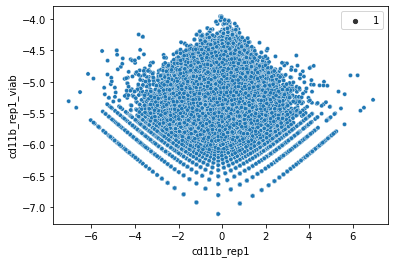

In [191]:
sns.scatterplot(x=cpm["cd11b_rep1"], y=np.log10(cpm["cd11b_rep1_viab"]), size=1)

In [172]:
cpm_median = cpm[["cd14", "cd11b_rep1", "cd11b_rep2", "gene"]].fillna(0)
cpm_median = cpm_median.replace(np.inf, 8)
cpm_median = cpm_median.replace(-np.inf, -8)
cpm_median = cpm_median.groupby(by="gene").median()

In [177]:
cpm_median.sort_values(by="cd11b_rep1").head(50)

,cd14,cd11b_rep1,cd11b_rep2
gene,,,
KAT2A,-0.517641,-4.315781,-3.461796
NUP62,-0.745481,-4.057548,-0.009846
TAF6L,-1.282823,-3.669604,-3.235045
TADA1,-1.276209,-3.657827,-2.194703
SUPT20H,-1.827663,-3.210123,-4.084730
SMARCE1,-0.293448,-3.042272,-3.010812
KMT2A,-1.661385,-3.015233,-2.992503
MEAF6,-1.736260,-2.904336,-2.936207
CBLL1,0.081105,-2.738110,-2.193863


In [174]:
cpm_median.sort_values(by="cd11b_rep1").to_csv("210717_bd191_genescores_sorted.csv")

(0.11992763228359404, 1.6625510400480364e-61)


/home/briando/data/software/miniconda3/envs/snakemake/lib/python3.9/site-packages/seaborn/_decorators.py:36: FutureWarning: Pass the following variables as keyword args: x, y. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(


<AxesSubplot:xlabel='cd14', ylabel='cd11b_rep1'>

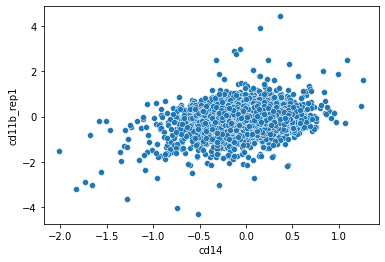

In [175]:
print(pearsonr(cpm_median["cd14"], cpm_median["cd11b_rep1"]))
sns.scatterplot(cpm_median["cd14"], cpm_median["cd11b_rep1"])

/home/briando/data/software/miniconda3/envs/snakemake/lib/python3.9/site-packages/seaborn/_decorators.py:36: FutureWarning: Pass the following variables as keyword args: x, y. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(


<AxesSubplot:xlabel='cd11b_rep2', ylabel='cd11b_rep1'>

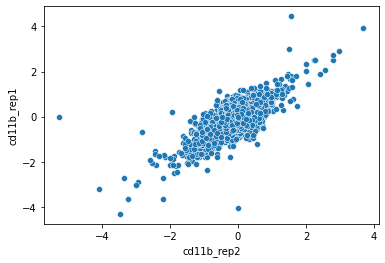

In [176]:
sns.scatterplot(cpm_median["cd11b_rep2"], cpm_median["cd11b_rep1"])

In [162]:
from scipy.stats import pearsonr
pearsonr(cpm_median["cd11b_rep2"], cpm_median["cd11b_rep1"])

(0.48141042581291227, 0.0)